# DNA-encoded library hit finding on the DD1S CAIX screen

**Jamal Shamsara**  ·  target: carbonic anhydrase (CAIX)

This notebook follows a DNA-encoded library (DEL) screen from its raw sequencing counts through to a ranked shortlist of building blocks.

The statistical core, the Anscombe-corrected enrichment with a Poisson confidence bound and the probabilistic training loss, is the work of Lim et al. (*J. Chem. Inf. Model.*, 2022) and their `del_qsar` code. I reimplemented those pieces in a current Python stack so the analysis runs on a laptop without the original environment, and built the rest around them: the building-block breakdown, the disynthon heatmaps, and the comparison of the three enrichment estimates.

The data is the public DD1S CAIX count file that ships with `del_qsar`.

---
*Method and data: Lim et al., "Machine learning on DNA-encoded library count data using an uncertainty-aware probabilistic loss function," J. Chem. Inf. Model. 2022; github.com/coleygroup/del_qsar. The enrichment statistics and probabilistic loss follow that work; the workflow, building-block analysis, heatmaps and comparisons are my own. This notebook was developed with the assistance of Claude (Anthropic) for coding and drafting; the analysis choices, validation and conclusions are mine.*

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw, rdFMCS, rdDepictor, rdFingerprintGenerator, rdRGroupDecomposition as rgd
%matplotlib inline

# ---- configuration ----
DATA      = "data/DD1S_CAIX_QSAR.csv"  # count file (copied from del_qsar, MIT-licensed)
N_BITS    = 1024      # Morgan fingerprint size for the model
EPOCHS    = 15        # training epochs for the probabilistic model
RETRAIN   = False     # True forces training; False reuses DD1S_CAIX_with_ml.csv if present, else trains
SEED      = 0
np.random.seed(SEED)
# On a fresh machine there is no cache, so the model cell trains an N_BITS-bit model from
# scratch (the one slow step). Everything else runs in seconds.

## 1. The dataset and its combinatorial structure

A DEL is built by *split-and-pool* combinatorial chemistry: a common core is grown over a few **cycles**, and in each cycle one **building block** is added together with a DNA barcode that records the choice. Every final compound is a unique combination of one building block per cycle, and its DNA tag is read out by sequencing after a selection against the target protein and against a no-protein control.

DD1S CAIX has three cycles. Below we confirm the size, the building blocks per cycle, and that the library is fully enumerated.

In [2]:
df = pd.read_csv(DATA)
df["smi"] = df["smiles"].str.replace("[No]", "[H]", regex=False)  # cap the DNA-linker placeholder
n1, n2, n3 = df.cycle1.nunique(), df.cycle2.nunique(), df.cycle3.nunique()
print(f"compounds: {len(df):,}")
print(f"building blocks per cycle -> cycle1: {n1}, cycle2: {n2}, cycle3: {n3}")
print(f"product {n1} x {n2} x {n3} = {n1*n2*n3:,}  (equals compound count -> fully enumerated)")

compounds: 108,528
building blocks per cycle -> cycle1: 8, cycle2: 114, cycle3: 119
product 8 x 114 x 119 = 108,528  (equals compound count -> fully enumerated)


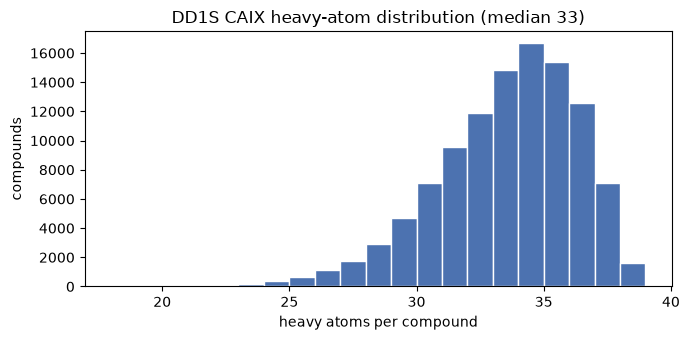

In [3]:
df["HA"] = df["smi"].apply(lambda s: Chem.MolFromSmiles(s).GetNumHeavyAtoms())
plt.figure(figsize=(7,3.5))
plt.hist(df["HA"], bins=range(df.HA.min(), df.HA.max()+2), color="#4C72B0", edgecolor="white")
plt.xlabel("heavy atoms per compound"); plt.ylabel("compounds")
plt.title(f"DD1S CAIX heavy-atom distribution (median {int(df.HA.median())})")
plt.tight_layout(); plt.show()

## 2. The building blocks

Heavy atoms are exactly additive in a fully enumerated library, so a linear decomposition recovers how many heavy atoms each building block contributes, which shows where the structural diversity lives.

In [4]:
from sklearn.linear_model import LinearRegression
X1h = pd.get_dummies(df[["cycle1","cycle2","cycle3"]].astype(str), drop_first=True).astype(float)
reg = LinearRegression().fit(X1h, df["HA"])
coef = dict(zip(X1h.columns, reg.coef_))
rows = []
for cyc in ["cycle1","cycle2","cycle3"]:
    vals = {i: coef.get(f"{cyc}_{i}", 0.0) for i in sorted(df[cyc].unique())}
    lo = min(vals.values())
    for i,v in vals.items(): rows.append({"cycle":cyc, "bb_id":i, "heavy_atoms_added":round(v-lo,1)})
bb = pd.DataFrame(rows)

print(f"Heavy atoms are exactly additive across the three cycles (regression R^2 = {reg.score(X1h, df.HA):.3f}).\n")
print("Heavy atoms ADDED by a building block, relative to the smallest block in its cycle")
print("(0 = smallest block in that cycle; this is how much SIZE each cycle contributes):\n")
print(bb.groupby("cycle")["heavy_atoms_added"].agg(["min","median","max"]).to_string())

Heavy atoms are exactly additive across the three cycles (regression R^2 = 1.000).

Heavy atoms ADDED by a building block, relative to the smallest block in its cycle
(0 = smallest block in that cycle; this is how much SIZE each cycle contributes):

        min  median   max
cycle                    
cycle1  0.0     0.5   1.0
cycle2  0.0     6.0   8.0
cycle3  0.0     9.0  11.0


So **cycle 1 barely changes the molecule (at most about one heavy atom), while cycles 2 and 3 carry essentially all the size diversity.** That is the first sign that cycle 1 is the central scaffold rather than a side group, which the next figures make concrete.

### 2a. Cycle 1: the central ring (drawn in context)

Cycle 1 cannot be drawn as a standalone fragment, because it is the core ring and varies by ring size and stereochemistry. To see it, we fix cycle 2 and cycle 3 and render the eight compounds that differ only in cycle 1, highlighting just the central saturated ring it controls.

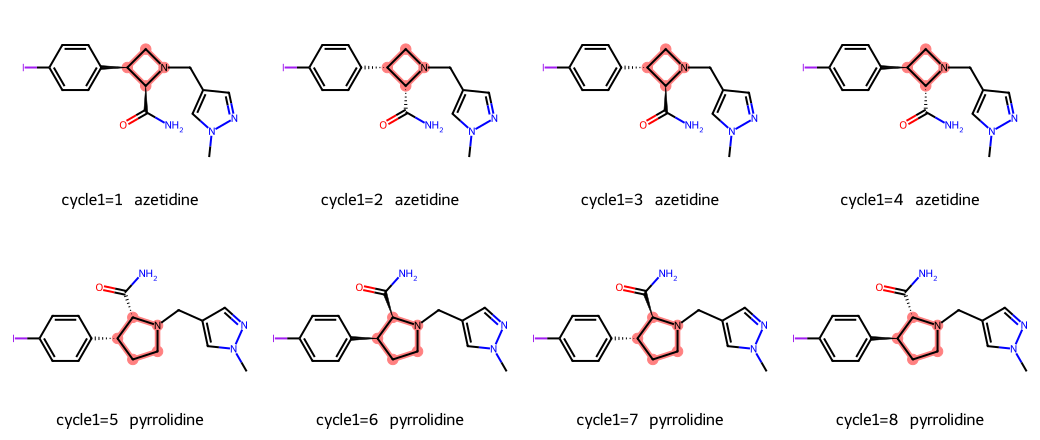

In [5]:
C2_FIX, C3_FIX = 7, 119
sub = df[(df.cycle2==C2_FIX) & (df.cycle3==C3_FIX)].sort_values("cycle1")
mols = [Chem.MolFromSmiles(s) for s in sub["smi"]]

mcs = rdFMCS.FindMCS(mols, timeout=30, completeRingsOnly=True, ringMatchesRingOnly=True)
templ = Chem.MolFromSmarts(mcs.smartsString); rdDepictor.Compute2DCoords(templ)
for m in mols: rdDepictor.GenerateDepictionMatching2DStructure(m, templ)

def saturated_N_ring(m):
    """atoms of the central saturated nitrogen ring = the cycle-1 scaffold."""
    for ring in m.GetRingInfo().AtomRings():
        ats = [m.GetAtomWithIdx(i) for i in ring]
        if any(a.GetSymbol()=="N" for a in ats) and all(not a.GetIsAromatic() for a in ats):
            return list(ring)
    return []
def ring_type(m):
    return {4:"azetidine",5:"pyrrolidine",6:"piperidine"}.get(len(saturated_N_ring(m)), "ring")

hl   = [saturated_N_ring(m) for m in mols]
legs = [f"cycle1={int(r.cycle1)}  {ring_type(m)}" for (_,r),m in zip(sub.iterrows(), mols)]
display(Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(260,220), legends=legs, highlightAtomLists=hl))

The eight cycle-1 variants are two ring sizes (azetidine for ids 1-4, pyrrolidine for ids 5-8, the single extra carbon the decomposition flagged) each in four stereochemical configurations. **A standard fingerprint ignores stereochemistry and barely registers a one-atom ring change, so the cycle-1 distinction is essentially invisible to fingerprint- and scaffold-based methods; it lives reliably only in the cycle-1 id.**

### 2b. Cycles 2 and 3: the R groups

These vary off the core, so they can be recovered cleanly as R groups. We decompose against both ring sizes so every compound matches, then draw the full building-block galleries.

In [6]:
cores = [Chem.MolFromSmarts("O=C([#7])C1C([*])CN1[*]"),    # 4-membered (azetidine)
         Chem.MolFromSmarts("O=C([#7])C1C([*])CCN1[*]")]   # 5-membered (pyrrolidine)
samp = df.sample(6000, random_state=SEED).reset_index(drop=True)
res, unmatched = rgd.RGroupDecompose(cores, [Chem.MolFromSmiles(s) for s in samp["smi"]], asSmiles=True)
rdf = pd.DataFrame(res); ok = samp.drop(index=unmatched).reset_index(drop=True)

colmap = {}
for col in [c for c in rdf.columns if c.startswith("R")]:
    for cyc in ["cycle2","cycle3"]:
        if pd.DataFrame({"r":rdf[col].values,"c":ok[cyc].values}).groupby("c")["r"].nunique().mean() < 1.5:
            colmap[cyc] = col
rep = {"cycle2":{}, "cycle3":{}}
for cyc,col in colmap.items():
    for frag,cid in zip(rdf[col].values, ok[cyc].values): rep[cyc].setdefault(int(cid), frag)
print(f"matched {len(ok)}/{len(samp)} sampled compounds; recovered R groups: "
      f"cycle2 {len(rep['cycle2'])}/{n2}, cycle3 {len(rep['cycle3'])}/{n3}")

matched 6000/6000 sampled compounds; recovered R groups: cycle2 114/114, cycle3 119/119


All 114 cycle2 building blocks:


/opt/miniconda3/envs/del/lib/python3.11/site-packages/rdkit/Chem/Draw/IPythonConsole.py:365: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


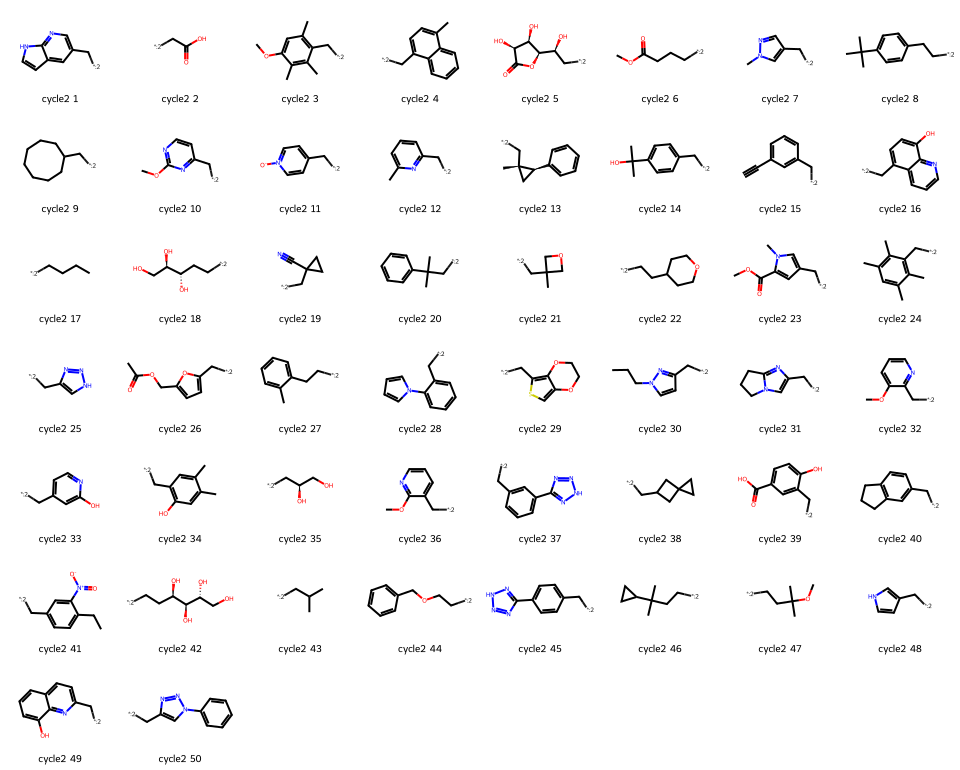

All 119 cycle3 building blocks:


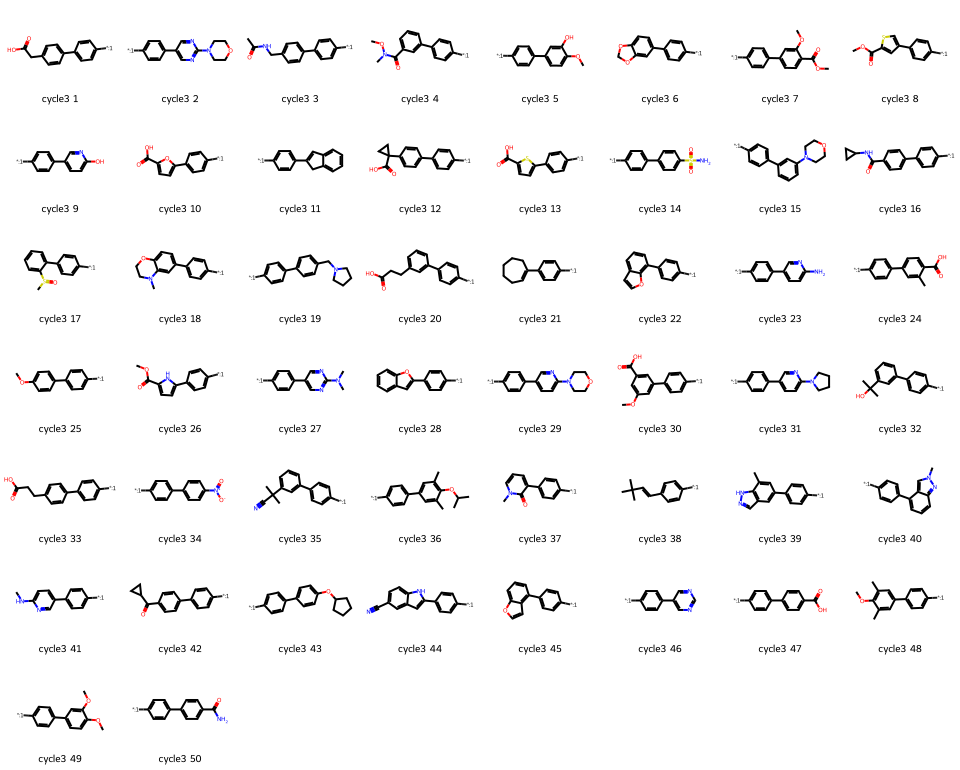

In [7]:
# full galleries of every recovered building block
for cyc in ["cycle2","cycle3"]:
    items = sorted(rep[cyc].items())
    print(f"All {len(items)} {cyc} building blocks:")
    display(Draw.MolsToGridImage([Chem.MolFromSmiles(s) for _,s in items], molsPerRow=8,
            subImgSize=(120,110), legends=[f"{cyc} {i}" for i,_ in items]))

## 3. From counts to enrichment

For each compound we have two read counts: protein-selection counts and no-protein control counts. Binding shows up as over-representation in the protein condition relative to control. We build this up in three steps, each fixing a problem with the previous one.

**Step 1 - raw enrichment.** The Anscombe-corrected ratio of normalized frequencies. A non-binder sits near 1.
**Step 2 - lower bound.** Counts are Poisson noise, so a ratio built on two reads is unreliable. The lower bound is the smallest enrichment still defensible at ~95% confidence; it stays high only when counts are large. A purely statistical, per-compound denoise (no structure).

In [8]:
def enrichment(k_prot, n_prot, k_ctrl, n_ctrl, z=0.0):
    """Anscombe-corrected enrichment with a normal-approximation confidence bound.
    z=0 -> point estimate; z=-2 -> ~95% lower bound. (after Lim et al., JCIM 2022)"""
    K1=np.asarray(k_prot,float); K2=np.asarray(k_ctrl,float)
    a=z**2/4-(K2+3/8); b=2*np.sqrt(K1+3/8)*np.sqrt(K2+3/8); c=z**2/4-(K1+3/8)
    x=(-b-np.sign(z)*np.sqrt(np.clip(b**2-4*a*c,0,None)))/(2*a)
    return x**2*(n_ctrl/n_prot)

N_PROT, N_CTRL = float(df.exp_tot.sum()), float(df.beads_tot.sum())
df["enrichment"]    = enrichment(df.exp_tot, N_PROT, df.beads_tot, N_CTRL, 0.0)
df["enrichment_lb"] = enrichment(df.exp_tot, N_PROT, df.beads_tot, N_CTRL, -2.0)

ex = df[((df.exp_tot==3)&(df.beads_tot==0)) | (df.exp_tot>100)].copy()
print("raw ratio rewards a lucky 3-read compound; the lower bound demotes it:\n")
print(ex.sort_values("enrichment",ascending=False)
        [["cpd_id","exp_tot","beads_tot","enrichment","enrichment_lb"]].head(4).to_string(index=False))

raw ratio rewards a lucky 3-read compound; the lower bound demotes it:

 cpd_id  exp_tot  beads_tot  enrichment  enrichment_lb
81976.0        3          0   73.374758       5.936186
26432.0      136         48   22.983595      16.632746
81053.0      118         66   14.539840      10.754444
13223.0      152         87   14.217744      10.913209


**Step 3 - structure-based model.** A neural network predicts enrichment from the molecule's fingerprint, trained with a probabilistic loss (Lim et al.) that compares the prediction to the *raw counts* under Poisson statistics, so low-count compounds are automatically down-weighted. This is the only step that uses structure.

In [9]:
import torch, torch.nn as nn, os
torch.manual_seed(SEED); torch.set_num_threads(4); SQRT2=np.sqrt(2.0); d=N_CTRL/N_PROT

class MLP(nn.Module):
    def __init__(s,n): super().__init__(); s.net=nn.Sequential(
        nn.Linear(n,512), nn.ReLU(), nn.Dropout(0.25), nn.Linear(512,128), nn.ReLU(), nn.Linear(128,1))
    def forward(s,x): return s.net(x).squeeze(-1)

def poisson_loss(R, k_prot, k_ctrl):
    Rd=R/d; z=2*(torch.sqrt(k_prot+.375)-torch.sqrt((k_ctrl+.375)*Rd))/torch.sqrt(1+Rd)
    return (-torch.log(torch.special.erfc(torch.abs(z)/SQRT2).clamp_min(1e-30))).mean()

cache_ok = (not RETRAIN) and os.path.exists("DD1S_CAIX_with_ml.csv")
if cache_ok:
    try:
        df["enrichment_ml"] = pd.read_csv("DD1S_CAIX_with_ml.csv")["enrichment_ml"].values
        print("loaded cached ML predictions")
    except Exception:
        cache_ok = False
if not cache_ok:
    print(f"training a {N_BITS}-bit model for {EPOCHS} epochs (this is the slow step)...")
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=N_BITS)
    Xfp = np.zeros((len(df), N_BITS), np.float32)
    for i,s in enumerate(df["smi"]):
        m=Chem.MolFromSmiles(s)
        if m is not None: Xfp[i]=gen.GetFingerprintAsNumPy(m).astype(np.float32)
    Xt=torch.from_numpy(Xfp)
    kp=torch.tensor(df.exp_tot.values,dtype=torch.float32); kc=torch.tensor(df.beads_tot.values,dtype=torch.float32)
    model=MLP(N_BITS); opt=torch.optim.Adam(model.parameters(),lr=1e-3); nrow=len(Xt)
    for ep in range(EPOCHS):
        perm=torch.randperm(nrow)
        for sidx in range(0,nrow,512):
            j=perm[sidx:sidx+512]; opt.zero_grad()
            R=torch.nn.functional.softplus(model(Xt[j]))+1e-6
            poisson_loss(R, kp[j], kc[j]).backward(); opt.step()
    model.eval()
    with torch.no_grad(): df["enrichment_ml"]=torch.nn.functional.softplus(model(Xt)).numpy()
    df.to_csv("DD1S_CAIX_with_ml.csv", index=False)
print("ML predicted enrichment range: %.2f .. %.2f" % (df.enrichment_ml.min(), df.enrichment_ml.max()))

loaded cached ML predictions
ML predicted enrichment range: 0.42 .. 11.38


The three estimates have visibly different distributions. The raw point estimate has a long tail of high values driven by low-count flukes; the lower bound pulls that tail in; the model output is tighter still and clusters near 1, the signature of heavy smoothing on a weak structure signal.

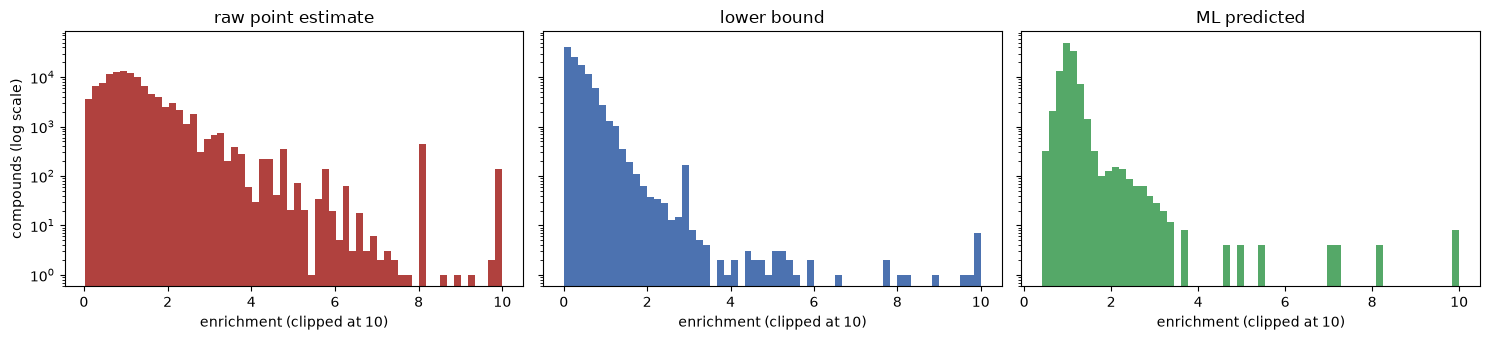

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15,3.5), sharey=True)
for a,(v,t,c) in zip(ax, [("enrichment","raw point estimate","#B0413E"),
                          ("enrichment_lb","lower bound","#4C72B0"),
                          ("enrichment_ml","ML predicted","#55A868")]):
    a.hist(df[v].clip(0,10), bins=60, color=c); a.set_yscale("log")
    a.set_title(t); a.set_xlabel("enrichment (clipped at 10)")
ax[0].set_ylabel("compounds (log scale)")
plt.tight_layout(); plt.show()

## 4. What "ground truth" means here (read before the heatmaps)

There is **no external ground truth of binding in this dataset**. All we observe are read counts. The "binder" labels people draw are just a threshold on enrichment, and the enrichment itself comes from those same counts. So every method below is judged against a count-derived proxy, not against measured affinity. True confirmation comes later and elsewhere: resynthesis off the DNA tag and a biochemical assay. This notebook stops at the counts, which is the prioritization step that decides which compounds earn that bench work.

## 5. Disynthon heatmaps

The natural unit of SAR in a DEL is the building block and the **disynthon** (a pair of building blocks). For each method we show the cycle 2 by cycle 3 disynthon map, the mean enrichment over the free cycle. The cycle-1 maps are near-flat, so this is the map carrying real SAR.

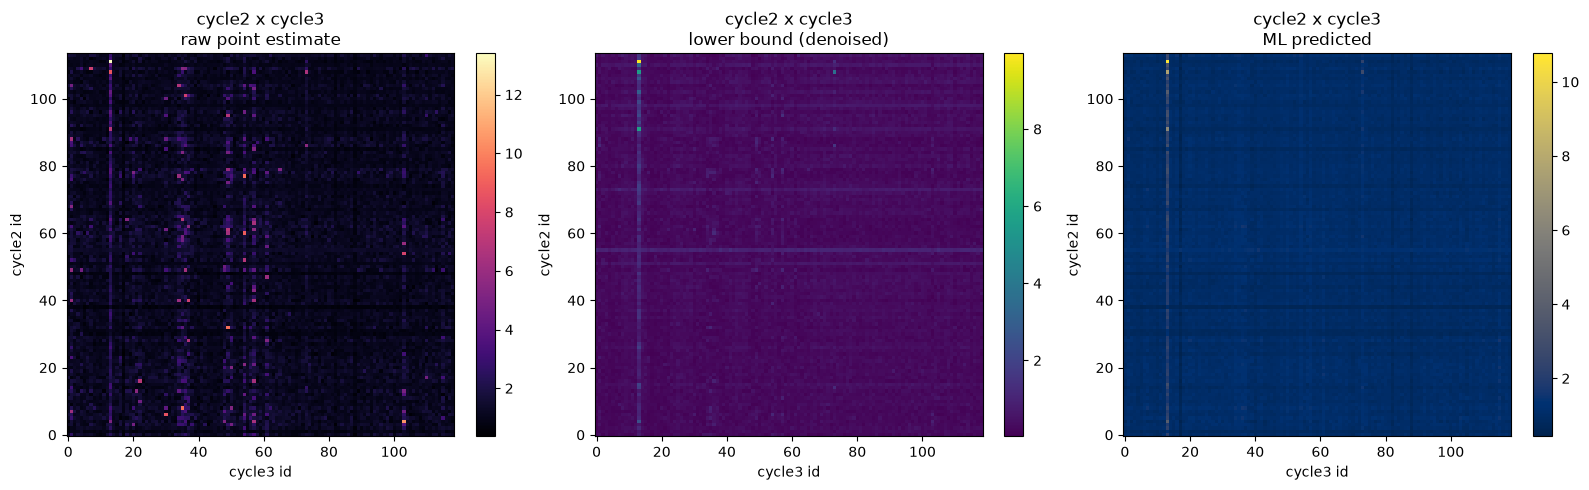

In [11]:
def disynthon(val, a="cycle2", b="cycle3"):
    return df.groupby([a,b])[val].mean().unstack(b)

fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax,(val,title,cmap) in zip(axes, [("enrichment","raw point estimate","magma"),
                                      ("enrichment_lb","lower bound (denoised)","viridis"),
                                      ("enrichment_ml","ML predicted","cividis")]):
    P=disynthon(val); im=ax.imshow(P.values, aspect="auto", cmap=cmap, origin="lower")
    ax.set_title(f"cycle2 x cycle3\n{title}"); ax.set_xlabel("cycle3 id"); ax.set_ylabel("cycle2 id")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## 6. Top building blocks and where the methods agree

We rank building blocks by mean enrichment under each method (the monosynthon view). The useful question is which blocks survive across methods that fail in different ways.

In [12]:
def top(val, cyc, k=10):
    g=df.groupby(cyc)[val].mean().sort_values(ascending=False).head(k)
    return [int(i) for i in g.index]
for cyc in ["cycle1","cycle2","cycle3"]:
    k = 2 if cyc=="cycle1" else 10
    print(f"{cyc} top {k}:")
    for val,lab in [("enrichment","raw"),("enrichment_lb","lower bound"),("enrichment_ml","ML")]:
        print(f"   {lab:12s}: {top(val,cyc,k)}")
    print()

cycle1 top 2:
   raw         : [7, 6]
   lower bound : [3, 4]
   ML          : [5, 6]

cycle2 top 10:
   raw         : [50, 79, 110, 63, 89, 9, 80, 65, 61, 87]
   lower bound : [56, 74, 99, 111, 52, 92, 114, 106, 103, 107]
   ML          : [56, 114, 63, 9, 29, 6, 53, 105, 60, 58]

cycle3 top 10:
   raw         : [14, 58, 55, 50, 36, 37, 2, 104, 35, 62]
   lower bound : [14, 74, 109, 15, 58, 44, 71, 10, 26, 55]
   ML          : [14, 74, 116, 58, 55, 37, 35, 51, 36, 62]



Cycle 3 id 14 sits at the top under all three methods. Cycle 3 ids 74, 58 and 55 and cycle 2 ids 56 and 114 recur across the noise-resistant methods (lower bound and ML). Beyond these the rankings diverge, especially cycle 1, whose top picks flip between methods, consistent with cycle 1 contributing almost nothing to bulk enrichment.

## 7. Depicting the top hits

The highest-ranked whole compounds by the lower bound and by the model, then the cross-method-robust building blocks.

Highest-ranked compounds by lower bound:


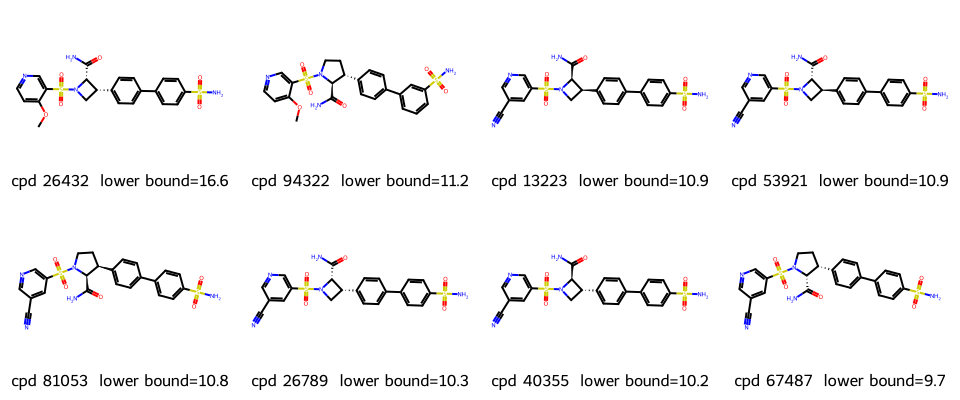

Highest-ranked compounds by ML model:


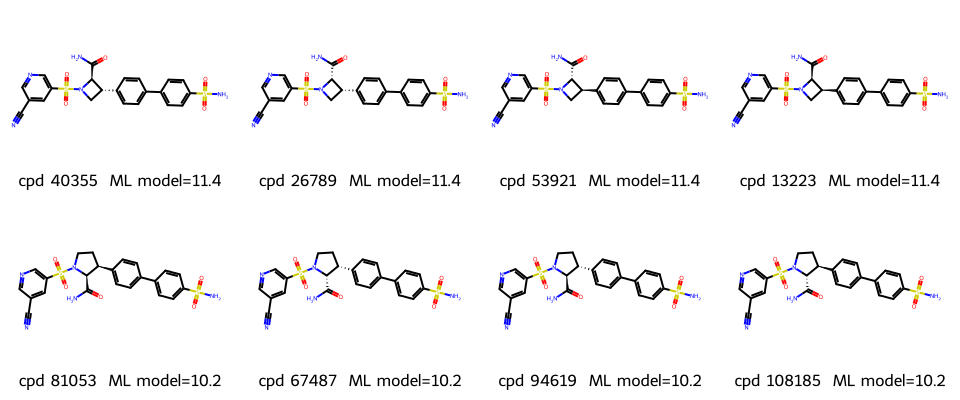

Cross-method robust building blocks:


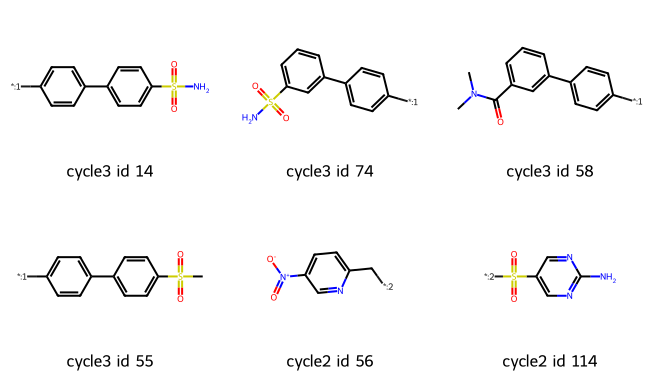

In [13]:
for metric,lab in [("enrichment_lb","lower bound"),("enrichment_ml","ML model")]:
    tc = df.sort_values(metric, ascending=False).head(8)
    print(f"Highest-ranked compounds by {lab}:")
    display(Draw.MolsToGridImage([Chem.MolFromSmiles(s) for s in tc["smi"]], molsPerRow=4,
            subImgSize=(240,200), legends=[f"cpd {int(r.cpd_id)}  {lab}={r[metric]:.1f}" for _,r in tc.iterrows()]))

shortlist = [("cycle3",14),("cycle3",74),("cycle3",58),("cycle3",55),("cycle2",56),("cycle2",114)]
ms = [Chem.MolFromSmiles(rep[c][i]) for c,i in shortlist if i in rep[c]]
lg = [f"{c} id {i}" for c,i in shortlist if i in rep[c]]
print("Cross-method robust building blocks:")
display(Draw.MolsToGridImage(ms, molsPerRow=3, subImgSize=(220,190), legends=lg))

## 8. Conclusion

- The lower bound is a simple, effective denoiser: it demotes low-count flukes below genuine high-count signal.
- SAR concentrates in the cycle 2 by cycle 3 combinations; cycle 1 barely affects enrichment.
- All three methods rank cycle 3 id 14 at the top; the lower bound and the model also agree on cycle 3 ids 74, 58, 55 and cycle 2 ids 56, 114.
- The structure-based model adds little here, tracking the measured signal only weakly. On this screen the statistics alone are enough to rank what was screened, which matches the source paper's finding of no extrapolation benefit.
- Real validation is off-DNA resynthesis and a biochemical assay of the top blocks, starting with cycle 3 id 14.